<h1><center>Практическое задание по дисциплине</center></h1>
<h1><center>«Теория принятия решений»</center></h1>
<h1><center>Вариант 76</center></h1>
<h1><center>Порофиев Е.А. группа 3375</center></h1>

## Задание №3.

### Постановка задачи
В задаче необходимо определить распределение рабочих, занимающихся добычей минералов, с учетом нескольких возможных сценариев развития событий.
У игрока есть две базы – Б1 (главная) и Б2 (вспомогательная, построенная недавно). На главной базе находится 8 источников минералов, на вспомогательной - 6. Всего у игрока 20
юнитов, которые могут вести добычу минералов («рабочих»), и 1000 минералов в запасе. Производство одного рабочего занимает 12 секунд и стоит 50 минералов (в упрощенной постановке
можно считать, что юниты, произведенные до атаки, не назначаются на добычу, а остаются в резерве – простаивают). Противник готовит атаку. Если атака будет на главную базу, часть рабочих, занятых добычей минералов на главной базе, погибнет. Если атака будет на вспомогательную базу, то погибнут все рабочие, осуществляющие добычу там (вспомогательная база защищена гораз-
до хуже). Необходимо решить, сколько рабочих следует держать на каждой базе и сколько оставить в резерве (простаивать), чтобы потом, после атаки, перераспределить выживших.

На основании имеющихся сведений можно выделить следующие сценарии:
 - Сценарий А ($50%$): Атака на главную базу. Погибнет 60% рабочих, занятых добычей на главной базе.
 - Сценарий Б ($50%$): Атака на вспомогательную базу. Погибнут все рабочие на этой базе.
    
Атака произойдет через 60 секунд. После атаки будет еще 120 секунд до решающей битвы, в течение которых игрок будет добывать ресурсы выжившими рабочими. Каждый рабочий добывает 1 минерал в секунду (упрощение), на базе может работать не более 2 рабочих на источник минералов, лишние простаивают. Считается, что в начальный момент времени все рабочие находятся на основной базе.
Необходимо найти план действий (распределение и производство), максимизирующий количество минералов. Запишите полную задачу линейного программирования с двумя сценариями в виде детерминированного эквивалента. Найдите оптимальное решение.

Проанализируйте полученное решение:
1. Приведите сведения об эффективности полученного решения в каждом из возможных сценариев.
2. Сравните оптимальное решение с эвристической стратегией «поровну на обе базы, резерва нет, новых после атаки не производим». Выигрывает ли найденная оптимальная стратегия?
3. Как изменится решение, если вероятность атаки на главную базу не $50/50$, а $80/20$?

## Математическая постановка задачи

### Переменные решения

- $x_1$ — количество рабочих, назначенных на главную базу до атаки;
- $x_2$ — количество рабочих, назначенных на вспомогательную базу до атаки;
- $p$ — количество новых рабочих, произведённых (и находящихся в резерве) до атаки;
- $y_{1A}$ — количество рабочих на главной базе после атаки в сценарии А;
- $y_{2A}$ — количество рабочих на вспомогательной базе после атаки в сценарии А;
- $y_{1B}$ — количество рабочих на главной базе после атаки в сценарии Б;
- $y_{2B}$ — количество рабочих на вспомогательной базе после атаки в сценарии Б.

Все переменные — неотрицательные вещественные (в непрерывной релаксации), но по смыслу задачи они целые. Допускается дробное решение с последующим округлением.

### Параметры задачи

- Начальный запас минералов: $M_0 = 1000$;
- Длительность первой фазы (до атаки): $T_1 = 60$ с;
- Длительность второй фазы (после атаки): $T_2 = 120$ с;
- Скорость добычи одного рабочего: $v = 1$ минерал/с;
- Стоимость производства одного рабочего: $c_p = 50$ минералов;
- Вместимость главной базы: $C_1 = 16$ рабочих (8 источников × 2);
- Вместимость вспомогательной базы: $C_2 = 12$ рабочих (6 источников × 2);
- Всего имеющихся рабочих в начальный момент: $N = 20$ (все находятся на главной базе, но могут быть перемещены);
- Вероятность сценария А (атака на главную базу): $\pi_A = 0.5$ (по умолчанию);
- Вероятность сценария Б (атака на вспомогательную базу): $\pi_B = 0.5$;
- Потери в сценарии А: на главной базе погибает $60\%$ рабочих, т.е. остаётся $0.4 x_1$; на вспомогательной — все $x_2$ выживают.
- Потери в сценарии Б: на вспомогательной базе погибают все рабочие, т.е. остаётся $0$; на главной — все $x_1$ выживают.
- Резерв $p$ (произведённые рабочие) не участвует в добыче до атаки и не гибнет, но может быть назначен на базы после атаки.

### Целевая функция (максимизация ожидаемого количества минералов к концу)

Ожидаемый доход складывается из:
1. Дохода до атаки (60 с): каждый из $x_1 + x_2$ рабочих приносит $60$ минералов.
2. Затрат на производство: $-50 p$ минералов.
3. Ожидаемого дохода после атаки:  
   - В сценарии А выжившие рабочие: $0.4 x_1 + x_2 + p$ (но они распределены по базам с учётом вместимости: $y_{1A} \le C_1$, $y_{2A} \le C_2$). Доход: $120(y_{1A} + y_{2A})$.  
   - В сценарии Б выжившие: $x_1 + 0 + p$, доход: $120(y_{1B} + y_{2B})$.


\[
\mathbb{E} = 60(x_1 + x_2) - 50p + 120\bigl(\pi_A (y_{1A}+y_{2A}) + \pi_B (y_{1B}+y_{2B})\bigr).
\]

Целевая функция:  
\[
\max \quad 60x_1 + 60x_2 - 50p + 120\pi_A y_{1A} + 120\pi_A y_{2A} + 120\pi_B y_{1B} + 120\pi_B y_{2B}.
\]

### Ограничения

#### 1. Ограничения на количество рабочих до атаки

- $x_1 \le C_1 = 16$ (главная база не более 16)
- $x_2 \le C_2 = 12$ (вспомогательная база не более 12)
- $x_1 + x_2 \le N = 20$ (нельзя использовать больше имеющихся рабочих)
- $p \le 20$ (разумное ограничение на производство, не более 20 новых рабочих)

#### 2. Ограничения на производство (расход минералов)

Производство $p$ рабочих стоит $50p$ минералов. Начальный запас $M_0 = 1000$.
Ограничение:

\[
50p \le M_0 = 1000 \quad \Rightarrow \quad p \le 20.
\]

#### 3. Связь переменных после атаки со сценариями

Для сценария А (атака на главную базу):
- Выжившие на главной: $0.4 x_1$, на вспомогательной: $x_2$, плюс резерв $p$.
- Эти рабочие распределяются по базам, но не могут превысить вместимость:
  \[
  y_{1A} \le 16,\quad y_{2A} \le 12.
  \]
- Кроме того, суммарное количество рабочих, назначенных на базы после атаки, не может превышать общее число выживших:
  \[
  y_{1A} + y_{2A} \le 0.4 x_1 + x_2 + p.
  \]

Аналогично для сценария Б (атака на вспомогательную базу):
- Выжившие: $x_1$ на главной, $0$ на вспомогательной, плюс $p$.
- Ограничения:
  \[
  y_{1B} \le 16,\quad y_{2B} \le 12,
  \]
  \[
  y_{1B} + y_{2B} \le x_1 + 0 + p = x_1 + p.
  \]

#### 4. Неотрицательность

$x_1, x_2, p, y_{1A}, y_{2A}, y_{1B}, y_{2B} \ge 0$.

### Детерминированный эквивалент (задача линейного программирования)

Собирая всё вместе, получаем следующую задачу ЛП:

\[
\begin{aligned}
\max \quad & 60x_1 + 60x_2 - 50p + 60y_{1A} + 60y_{2A} + 60y_{1B} + 60y_{2B} \\
\text{при условиях:} \quad
& x_1 \le 16 \\
& x_2 \le 12 \\
& x_1 + x_2 \le 20 \\
& p \le 20 \\
& 0.4x_1 + x_2 + p - y_{1A} - y_{2A} \ge 0 \quad (\text{иначе } y_{1A}+y_{2A} \le 0.4x_1+x_2+p) \\
& x_1 + p - y_{1B} - y_{2B} \ge 0 \\
& y_{1A} \le 16,\; y_{2A} \le 12,\; y_{1B} \le 16,\; y_{2B} \le 12 \\
& x_1, x_2, p, y_{1A}, y_{2A}, y_{1B}, y_{2B} \ge 0.
\end{aligned}
\]


### Метод решения

#### Приведение к канонической форме

Общая задача:

\[
\begin{aligned}
\max \quad & \mathbf{c}^T \mathbf{x} \\
\text{при} \quad & \mathbf{A} \mathbf{x} \le \mathbf{b}, \\
& \mathbf{x} \ge 0,
\end{aligned}
\]

где $\mathbf{x} = (x_1, x_2, p, y_{1A}, y_{2A}, y_{1B}, y_{2B})^T$, $\mathbf{c}$ — вектор коэффициентов целевой функции, $\mathbf{A}$ — матрица ограничений (10×7), $\mathbf{b}$ — вектор правых частей.

Каждое неравенство $a_i^T \mathbf{x} \le b_i$ преобразуется в равенство путём добавления неотрицательной слабой переменной $s_i$:

\[
a_i^T \mathbf{x} + s_i = b_i, \quad s_i \ge 0.
\]

После этого получается система $m = 10$ уравнений с $n + m = 7 + 10 = 17$ переменными. Симплекс-метод работает непосредственно с этой расширенной системой.

#### Симплекс-таблица

Все коэффициенты заносятся в симплекс-таблицу размера $(m+1) \times (n + m + 1)$:

- первые $m$ строк соответствуют ограничениям;
- последняя $(m+1)$-я строка содержит коэффициенты целевой функции, взятые с **обратным знаком** (для максимизации);
- первые $n$ столбцов — исходные переменные;
- следующие $m$ столбцов — слабые переменные;
- последний столбец — правые части уравнений.

Начальная таблица имеет вид:

\[
\begin{array}{c|cccc|c}
 & x_1 \dots x_n & s_1 \dots s_m & & \text{Правая часть} \\ \hline
\text{Ограничения} & \mathbf{A} & \mathbf{I}_m & & \mathbf{b} \\
\text{Целевая функция} & -\mathbf{c}^T & \mathbf{0}^T & & 0
\end{array}
\]

В нашем случае $\mathbf{c} = [60, 60, -50, 60, 60, 60, 60]$, поэтому в последней строке первые 7 элементов равны $[-60, -60, 50, -60, -60, -60, -60]$.

#### Алгоритм симплекс-метода (максимизация)

**Шаг 1. Проверка оптимальности.**  
Если в последней строке (игнорируя последний столбец) **нет отрицательных элементов** (с учётом заданной точности $\varepsilon = 10^{-9}$), текущее базисное решение оптимально. Переход к шагу 5.

**Шаг 2. Выбор ведущего столбца.**  
Среди отрицательных элементов последней строки выбирается **наименьший** (наиболее отрицательный). Его столбец $j^*$ становится ведущим. Это соответствует переменной, увеличение которой быстрее всего повышает целевую функцию.

**Шаг 3. Выбор ведущей строки.**  
Для всех ограничений $i = 1,\dots,m$, у которых элемент в ведущем столбце $a_{i,j^*}$ **положителен**, вычисляется отношение:

\[
\theta_i = \frac{b_i}{a_{i,j^*}}.
\]

Строка с **минимальным положительным** отношением выбирается в качестве ведущей $i^*$. Если ни одного положительного элемента нет — задача **неограничена** (целевая функция может расти бесконечно).

**Шаг 4. Преобразование таблицы (метод Гаусса–Жордана).**  
- Ведущий элемент $a_{i^*,j^*}$ делит всю ведущую строку на себя (делает его равным 1).  
- Для всех остальных строк $i \neq i^*$ выполняется:  
  \[
  \text{строка}_i := \text{строка}_i - a_{i,j^*} \cdot \text{строка}_{i^*}.
  \]  
  Это обнуляет ведущий столбец во всех строках, кроме ведущей. После этого переменная, соответствующая ведущему столбцу, становится **базисной**, а переменная, ранее бывшая базисной в ведущей строке (слабая переменная), выходит из базиса.

Переход к шагу 1.

**Шаг 5. Извлечение оптимального решения.**  
- Для каждой исходной переменной $x_j$ ($j=1,\dots,n$) анализируется её столбец в первых $m$ строках таблицы.  
- Если в этом столбце **ровно один элемент равен 1**, а остальные (с учётом $\varepsilon$) равны 0, то переменная является базисной, и её значение равно правой части в той строке, где находится 1.  
- В противном случае переменная **небазисная** и принимается равной 0.  

Значение целевой функции берётся из правого нижнего угла таблицы (последняя строка, последний столбец).

#### Обработка особых случаев

- **Точность:** все сравнения с нулём выполняются с допуском $\varepsilon = 10^{-9}$, чтобы избежать ошибок округления.
- **Зацикливание:** в данной реализации не предусмотрены антицикличные правила (например, правило Блэнда), но для задач малой размерности циклы практически не возникают. При необходимости можно добавить случайный выбор ведущего элемента.
- **Целочисленность:** после получения оптимального непрерывного решения переменные $x_1, x_2, p$ округляются до ближайших целых (в задаче они целые по смыслу). Остальные переменные могут быть дробными, но в оптимальной точке обычно также целые.

#### Вычислительная сложность

Симплекс-метод в худшем случае имеет экспоненциальную сложность, но на практике для задачи с $m=10$ ограничениями и $n=7$ переменными сходится за $O(m)$.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def simplex_maximize(c, A_ub, b_ub, eps=1e-9):
    m, n = A_ub.shape
    num_slack = m
    
    tableau = np.zeros((m + 1, n + num_slack + 1))
    tableau[:m, :n] = A_ub
    tableau[:m, n:n+num_slack] = np.eye(num_slack)
    tableau[:m, -1] = b_ub
    tableau[-1, :n] = -c 

    #print(tableau)
    
    while True:
        last_row = tableau[-1, :-1]
        neg_mask = last_row < -eps
        
        if not np.any(neg_mask):
            break
            
        pivot_col = np.argmin(last_row)
        
        ratios = np.full(m, np.inf)
        
        for i in range(m):
            if tableau[i, pivot_col] > eps:
                ratios[i] = tableau[i, -1] / tableau[i, pivot_col]
                
        if np.all(np.isinf(ratios)):
            raise ValueError("Задача неограничена")
            
        pivot_row = np.argmin(ratios)
        
        pivot_val = tableau[pivot_row, pivot_col]
        tableau[pivot_row, :] /= pivot_val
        
        for i in range(m + 1):
            if i != pivot_row:
                factor = tableau[i, pivot_col]
                tableau[i, :] -= factor * tableau[pivot_row, :]
                
    x = np.zeros(n)
    for j in range(n):
        col = tableau[:m, j]
        if np.sum(np.isclose(col, 1.0)) == 1 and np.sum(np.isclose(col, 0.0)) == m - 1:
            row_idx = np.argmax(col)
            x[j] = tableau[row_idx, -1]
            
    optimal_value = tableau[-1, -1]
    return x, optimal_value


def solve_mineral_problem(prob_a=0.5):
    prob_b = 1.0 - prob_a
    
    c = np.array([60, 60, -50, 
                  120*prob_a, 120*prob_a, 
                  120*prob_b, 120*prob_b])
    
    A_ub = np.array([
        [1, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0.4, 0, -1, 1, 1, 0, 0],
        [0, 1, -1, 0, 0, 1, 1],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 1]
    ])
    b_ub = np.array([16, 12, 20, 20, 20, 20, 16, 12, 16, 12])
    
    x, obj_val = simplex_maximize(c, A_ub, b_ub)
    return {
        'x1': round(x[0]), 'x2': int(x[1]), 'p': int(x[2]),
        'y1A': x[3], 'y2A': x[4], 'y1B': x[5], 'y2B': x[6],
        'expected_minerals': obj_val + 1000,
        'prob_a': prob_a, 'prob_b': prob_b
    }


def scenario_result(sol, scenario):
    if scenario == 'A':
        y1, y2 = sol['y1A'], sol['y2A']
    else:
        y1, y2 = sol['y1B'], sol['y2B']
    return 1000 + 60*(sol['x1']+sol['x2']) - 50*sol['p'] + 120*(y1+y2)

In [11]:
print("Решение с вероятностью 50/50")

sol = solve_mineral_problem(0.5)

print(f"До атаки: Б1={sol['x1']:.2f}, Б2={sol['x2']:.2f}, Производство={sol['p']:.2f}")
print(f"После атаки А: Б1={sol['y1A']:.2f}, Б2={sol['y2A']:.2f}")
print(f"После атаки Б: Б1={sol['y1B']:.2f}, Б2={sol['y2B']:.2f}")
print(f"Ожидаемый итог: {sol['expected_minerals']:.2f} минералов\n")


print(f"Сценарий А (атака на Б1): {scenario_result(sol, 'A'):.2f} мин.")
print(f"Сценарий Б (атака на Б2): {scenario_result(sol, 'B'):.2f} мин.\n")

Решение с вероятностью 50/50
До атаки: Б1=14.00, Б2=5.00, Производство=13.00
После атаки А: Б1=16.00, Б2=12.00
После атаки Б: Б1=16.00, Б2=12.00
Ожидаемый итог: 4874.29 минералов

Сценарий А (атака на Б1): 4850.00 мин.
Сценарий Б (атака на Б2): 4850.00 мин.



## 2. Сравнение с эвристикой "поровну, без резерва"

In [12]:
print("2. Поровну, без резерва, без производства")

x1_h, x2_h, p_h = 10, 10, 0

avail_A = 20 - 0.6*x1_h + p_h
avail_B = 20 - x2_h + p_h

yA = min(avail_A, 28)
yB = min(avail_B, 28)
exp_h = 0.5*(1000 + 60*20 - 50*p_h + 120*yA) + 0.5*(1000 + 60*20 - 50*p_h + 120*yB)

print(f"Ожидаемый итог: {exp_h:.2f} минералов")
print(f"Выигрыш оптимальной стратегии: {sol['expected_minerals'] - exp_h:.2f} мин. ({((sol['expected_minerals']/exp_h)-1)*100:.1f}%)\n")

2. Поровну, без резерва, без производства
Ожидаемый итог: 3640.00 минералов
Выигрыш оптимальной стратегии: 1234.29 мин. (33.9%)



## 3. Случай с вероятностями 80/20 (атака на Б1 более вероятна)

In [6]:
print("3. Решение с вероятностью 80/20")
sol80 = solve_mineral_problem(0.8)
print(f"До атаки: Б1={sol80['x1']:.2f}, Б2={sol80['x2']:.2f}, Производство={sol80['p']:.2f}")
print(f"После атаки А: Б1={sol80['y1A']:.2f}, Б2={sol80['y2A']:.2f}")
print(f"После атаки Б: Б1={sol80['y1B']:.2f}, Б2={sol80['y2B']:.2f}")
print(f"Ожидаемый итог: {sol80['expected_minerals']:.2f} минералов")

3. Решение с вероятностью 80/20
До атаки: Б1=14.00, Б2=5.00, Производство=13.00
После атаки А: Б1=16.00, Б2=12.00
После атаки Б: Б1=16.00, Б2=12.00
Ожидаемый итог: 4874.29 минералов


## 4. График зависимости максимального ожидаемого дохода от вероятности атаки на Б1

Построение графика зависимости Z_max от вероятности атаки на Б1



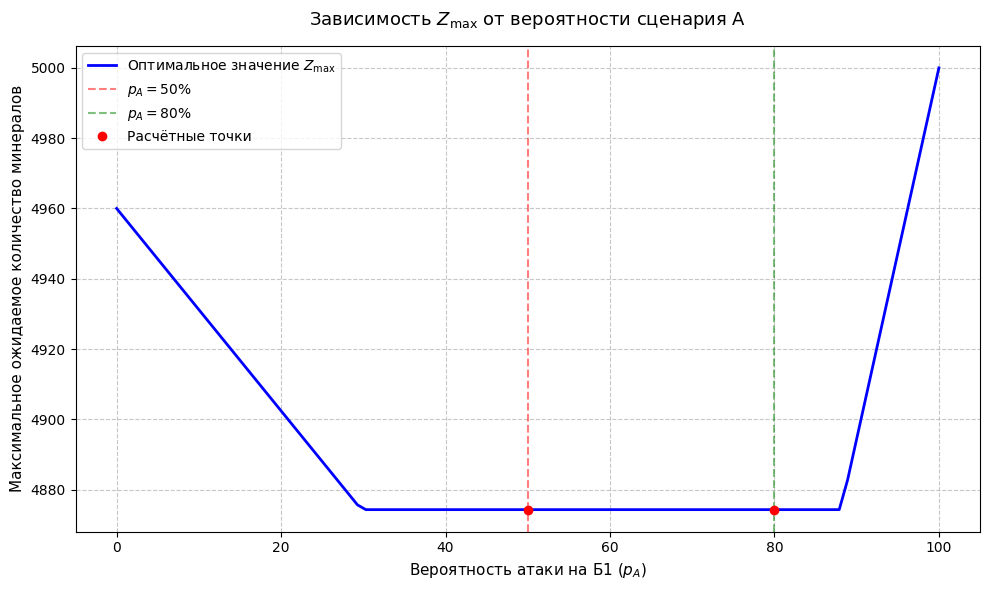


Ключевые точки на графике:
  p_A = 0% → Z_max = 4960.00
  p_A = 50% → Z_max = 4874.29
  p_A = 80% → Z_max = 4874.29
  p_A = 100% → Z_max = 5000.00


In [13]:
import matplotlib.pyplot as plt

print("Построение графика зависимости Z_max от вероятности атаки на Б1\n")

probabilities = np.linspace(0, 1, 100)
max_minerals = [solve_mineral_problem(prob_a=p)['expected_minerals'] for p in probabilities]

plt.figure(figsize=(10, 6))

plt.plot(probabilities * 100, max_minerals, 'b-', linewidth=2, 
         label=r'Оптимальное значение $Z_{\max}$')

plt.xlabel(r'Вероятность атаки на Б1 ($p_A$)', fontsize=11)
plt.ylabel('Максимальное ожидаемое количество минералов', fontsize=11)
plt.title(r'Зависимость $Z_{\max}$ от вероятности сценария А', fontsize=13, pad=15)

plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=50, color='r', linestyle='--', alpha=0.5, label=r'$p_A = 50\%$')
plt.axvline(x=80, color='g', linestyle='--', alpha=0.5, label=r'$p_A = 80\%$')

sol_50 = solve_mineral_problem(0.5)
sol_80 = solve_mineral_problem(0.8)
plt.plot([50, 80], [sol_50['expected_minerals'], sol_80['expected_minerals']], 
         'ro', markersize=6, label='Расчётные точки')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nКлючевые точки на графике:")
for p in [0.0, 0.5, 0.8, 1.0]:
    sol = solve_mineral_problem(p)
    print(f"  p_A = {p*100:.0f}% → Z_max = {sol['expected_minerals']:.2f}")